In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import networkx as nx

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from data_processing.pyg_graph_generator import *
from data_processing.sample_scoring import *

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Conclusion on the difference between CLEP_resource and MY implementation
1. Processed ADNI Gene Expression data:
   1. The number of Genes are different: $CLEP$ didn't merge the raw gene profile of the same gene names
   2. The columns of Gene Symbols are different: Not sure if we use the same platform file to rename the columns;
   3. Not sure if $CLEP$ did the correct way which can give better performance: because somehow without merging the columns of same genes, `sample_scoring` gives more connections to each sample.
2. Sample Scoring:
   1. The essence method is the same;
   2. But the statistification of summary is different, $CLEP$ count the number of +1, -1 values of genes in `network_summary.tsv` while that count is not real connected edges due to missing the non-overlapped proteins in KG;
   3. $My$ `network_summary` correctly counts the number of positive and negative edges each sample connected to KG proteins;
3. Network Generator:
   1. Both $CLEP$ and $MY$ `network_generator()` construct the same network, while $CLEP$ count the pos_ and neg_ edges wrong due to missing counting the genes in edges_to_remove;
   2. $MY$ `graph_generator()` can generate the correct network and also give the correct counting of connected edges and genes.

In [2]:
def plot_venn(set1, set2, label1, label2):
    plt.figure(figsize=(6,4))
    venn2(subsets=(set1, set2), set_labels=(label1, label2))
    plt.title("Overlapping Proteins")
    plt.show()

# Old PPI-KG

In [3]:
ppi_kg = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/data/ppi-kg.edgelist", sep='\t')
ppi_kg

,source,relation,target
0,USP7,decreases,TP53
1,SFN,association,SYNJ2
2,PAK1,association,PIK3CB
3,BIRC6,association,MAP2K1
4,AXIN1,association,SMAD7
...,...,...,...
209814,XRCC5,increases,ATRIP
209815,ZFYVE16,regulates,SMAD4
209816,ZNF655,increases,SP1
209817,ZNF655,increases,FADD


In [4]:
ppi_kg.isna().sum()

source      48
relation     0
target      50
dtype: int64

In [5]:
cleaned_ppi_df = ppi_kg.dropna()
cleaned_ppi_df

,source,relation,target
0,USP7,decreases,TP53
1,SFN,association,SYNJ2
2,PAK1,association,PIK3CB
3,BIRC6,association,MAP2K1
4,AXIN1,association,SMAD7
...,...,...,...
209814,XRCC5,increases,ATRIP
209815,ZFYVE16,regulates,SMAD4
209816,ZNF655,increases,SP1
209817,ZNF655,increases,FADD


In [6]:
old_ppi_kg = nx.MultiDiGraph()
for i, row in ppi_kg.iterrows():
    src = row['source']
    dst = row['target']
    rel = row['relation']
    
    # 1. Robustly check for NaN (catches both float nan and string 'nan')
    if pd.isna(src) or str(src).lower() == 'nan' or pd.isna(dst) or str(dst).lower() == 'nan':
        continue # Skip this broken triple entirely
        
    # 2. Add nodes safely
    if src not in old_ppi_kg:
        old_ppi_kg.add_node(src, label='Protein')
    if dst not in old_ppi_kg:
        old_ppi_kg.add_node(dst, label='Protein')
        
    # 3. Add edge safely
    old_ppi_kg.add_edge(src, dst, relation=rel)

# save graph
with open("../datasets/base_kgs/oldcleaned_ppi_kg.pkl",'wb') as f:
    pickle.dump(old_ppi_kg, f)
print(f"Save graph of {old_ppi_kg.number_of_nodes()} nodes and {old_ppi_kg.number_of_edges()} edges")

Save graph of 8910 nodes and 209730 edges


### Load ADNI Data

In [7]:
clep_scoring_ecdf5 = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/5/sample_scoring.tsv", sep=r'[,\t\s]+', engine='python', index_col=0)
my_scoring_ecdf1 = pd.read_csv("../data/ADNI/old_target/ecdf_1/sample_scoring_ecdf.csv", sep=r'[,\t\s]+', engine='python', index_col=0)
clep_scoring_ecdf1 = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/sample_scoring.tsv", sep='\t', index_col=0)
my_scoring_ecdf5 = pd.read_csv("../data/ADNI/old_target/ecdf_5/sample_scoring_ecdf.csv", sep=r'[,\t\s]+', engine='python', index_col=0)

In [8]:
# The ADNI data I am using
exp_path = "../data/ADNI/cleaned_gene_expression_data.csv"
exp_df = pd.read_csv(exp_path, index_col=0)
exp_df = exp_df.T

In [9]:
# check if the samples and labels the same
sample_label_map = clep_scoring_ecdf5['label'].to_dict()
sample_label_map_1 = clep_scoring_ecdf1['label'].to_dict()
print(sample_label_map == sample_label_map_1)

my_sample_label_map = my_scoring_ecdf1['label'].to_dict()
print(my_sample_label_map == sample_label_map)

True
True


### Sample Scoring Result Comparison

In [10]:
my_gene_symbols = list(my_scoring_ecdf1.columns)[:-1]
clep_gene_symbols = list(clep_scoring_ecdf1.columns)[:-1]
common_columns = set(my_gene_symbols) & set(clep_gene_symbols)
comparison = clep_scoring_ecdf1[list(common_columns)] == my_scoring_ecdf1[list(common_columns)]
(~comparison).sum().sum()

289080

In [11]:
my_scoring_ecdf1[list(common_columns)].apply(pd.Series.value_counts, axis=1)

,-1,0,1
116_S_1249,323,19912,181
037_S_4410,795,19031,590
006_S_4153,52,20166,198
116_S_1232,50,20252,114
099_S_4205,148,20187,81
...,...,...,...
009_S_2381,116,20074,226
053_S_4557,52,20265,99
073_S_4300,192,20158,66
041_S_4014,318,19407,691


In [12]:
clep_scoring_ecdf1[list(common_columns)].apply(pd.Series.value_counts, axis=1)

,-1,0,1
116_S_1249,341,19834,241
037_S_4410,521,19472,423
006_S_4153,66,20190,160
116_S_1232,66,20217,133
099_S_4205,131,20201,84
...,...,...,...
009_S_2381,138,20048,230
053_S_4557,89,20213,114
073_S_4300,160,20170,86
041_S_4014,333,19396,687


In [13]:
my_scoring_ecdf5[list(common_columns)].apply(pd.Series.value_counts, axis=1)

,-1,0,1
116_S_1249,1392,18089,935
037_S_4410,3032,15170,2214
006_S_4153,504,19234,678
116_S_1232,452,19156,808
099_S_4205,1183,18645,588
...,...,...,...
009_S_2381,713,18557,1146
053_S_4557,414,19188,814
073_S_4300,985,19034,397
041_S_4014,1525,15947,2944


In [14]:
clep_scoring_ecdf5[list(common_columns)].apply(pd.Series.value_counts, axis=1)

,-1,0,1
116_S_1249,1390,17899,1127
037_S_4410,2360,16169,1887
006_S_4153,562,19245,609
116_S_1232,532,19050,834
099_S_4205,1027,18735,654
...,...,...,...
009_S_2381,763,18572,1081
053_S_4557,516,19059,841
073_S_4300,929,18997,490
041_S_4014,1545,16103,2768


### Overlapping Proteins Comparison

The number of Cleaned PPI-KG Proteins: 8910
The number of CLEP GE Proteins: 49945


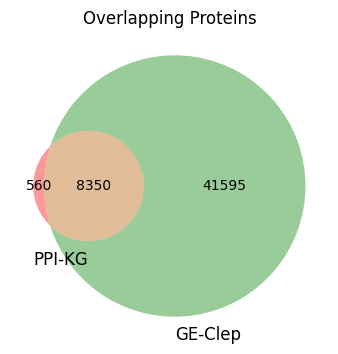

In [15]:
PPI_Proteins = set(cleaned_ppi_df['source'].unique()) | set(cleaned_ppi_df['target'].unique())
print(f"The number of Cleaned PPI-KG Proteins: {len(PPI_Proteins)}")
GE_clep = set(clep_scoring_ecdf1.columns)
print(f"The number of CLEP GE Proteins: {len(GE_clep)}")
plot_venn(PPI_Proteins, GE_clep, 'PPI-KG', "GE-Clep")

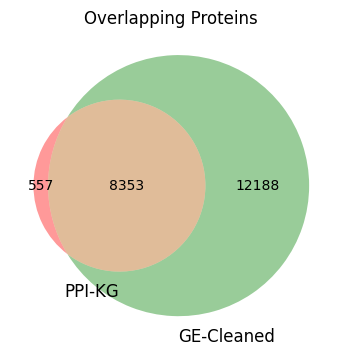

In [16]:
plot_venn(PPI_Proteins, set(exp_df.columns), 'PPI-KG', "GE-Cleaned")

In [17]:
common_cleaned_ppi = PPI_Proteins & set(exp_df.columns)
common_raw_ppi = PPI_Proteins & GE_clep
difference_prs = common_cleaned_ppi - common_raw_ppi
difference_prs

{'CACNG4', 'KLRC2', 'ZNF316'}

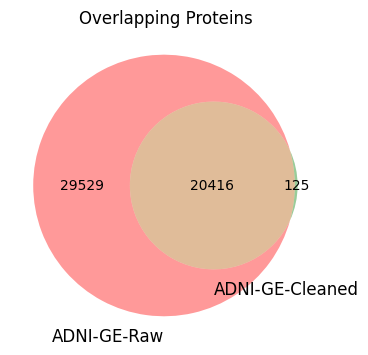

In [18]:
plot_venn(GE_clep, set(exp_df.columns), 'ADNI-GE-Raw', 'ADNI-GE-Cleaned')

In [19]:
adni_raw = pd.read_csv("../data/ADNI/adni_raw_data.csv", sep=None, engine='python',index_col=0)
adni_raw

,11715100_at,11715101_s_at,11715102_x_at,11715103_x_at,11715104_s_at,11715105_at,11715106_x_at,11715107_s_at,11715108_x_at,11715109_at,...,AFFX-r2-TagIN-3_at,AFFX-r2-TagIN-5_at,AFFX-r2-TagIN-M_at,AFFX-r2-TagJ-3_at,AFFX-r2-TagJ-5_at,AFFX-r2-TagO-3_at,AFFX-r2-TagO-5_at,AFFX-r2-TagQ-3_at,AFFX-r2-TagQ-5_at,Label
116_S_1249,2.237,2.624,1.873,2.920,2.147,2.268,2.432,4.600,2.771,2.931,...,2.624,2.010,2.906,2.463,2.050,2.060,1.858,2.028,2.162,0
037_S_4410,2.294,2.416,1.884,2.668,2.156,2.130,2.270,4.547,2.363,2.548,...,2.820,1.726,2.465,2.260,1.933,1.717,2.208,2.058,1.882,0
006_S_4153,2.140,2.322,1.999,3.634,2.516,1.957,2.333,4.442,2.544,2.814,...,2.455,1.840,2.681,2.251,1.985,1.770,2.184,2.007,2.134,1
116_S_1232,2.062,2.500,1.851,3.632,2.283,2.347,2.258,4.608,2.233,3.156,...,2.599,1.837,2.713,2.158,1.916,1.878,2.163,2.185,2.099,0
099_S_4205,2.040,2.395,2.080,3.278,2.251,2.154,2.334,4.536,2.546,2.864,...,2.544,1.909,2.548,2.266,2.077,1.838,2.085,1.941,1.883,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,2.382,2.277,2.107,3.819,2.588,2.201,2.531,4.455,2.335,2.949,...,2.937,1.964,2.662,2.478,2.017,1.886,2.371,1.997,1.996,1
053_S_4557,2.497,2.466,2.137,3.541,2.256,2.205,2.737,4.725,2.078,2.863,...,2.585,1.997,2.732,2.181,1.885,1.742,2.177,2.176,2.151,1
073_S_4300,2.309,2.607,2.075,3.496,2.098,2.161,2.439,4.981,2.394,2.775,...,2.464,1.924,2.613,2.269,1.807,1.781,2.110,1.875,1.915,1
041_S_4014,2.302,2.569,2.147,4.037,2.376,2.130,2.585,5.005,2.396,2.491,...,2.695,2.108,2.661,2.383,2.188,1.740,2.501,2.070,2.151,0


# Network Generation result compariosn

In [20]:
my_ecdf1_path = "../data/ADNI/old_target/ecdf_1/sample_scoring_ecdf.csv"
clep_ecdf1_path = "../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/sample_scoring.tsv"
kg_disease_path = "../datasets/base_kgs/old_ppi_kg.pkl"
kg_health_path = "../data/KG/healthy_aging_reversed_remove_noncausal.pkl"

In [21]:
# 1. Load expression df, smaple scoring df, KG
if exp_df.shape[0] > exp_df.shape[1]:
    exp_df = exp_df.transpose()

data = pd.read_csv(clep_ecdf1_path, sep=r'[,\t\s]+', engine='python',index_col=0)
kg_disease = load_graph(kg_disease_path)
kg_control = load_graph(kg_health_path)

# clean exp_df before K-NN
# drop genes with no variation
exp_df = exp_df.loc[:, exp_df.std() > 0]
# Using median is usually safer for gene expression
exp_df = exp_df.fillna(exp_df.median())
# normalize safely
min_val = exp_df.min()
max_val = exp_df.max()
exp_norm = (exp_df - min_val) / (max_val - min_val + 1e-9)
# final fill-na
exp_norm = exp_norm.fillna(0)

# 2. Generate PatientNetwork
png = PatientNetworkGenerator(kg_disease=kg_disease,
                                kg_healthy=kg_control)

Loaded graph from ../datasets/base_kgs/old_ppi_kg.pkl: 8910 nodes, 209730 edges
Loaded graph from ../data/KG/healthy_aging_reversed_remove_noncausal.pkl: 4161 nodes, 13775 edges


## My Network Generator Using Clep sample_scoring.csv, threshold=1
+ using my sample scoring

In [22]:
network_my_ecdf1, summary_my_ecdf1 = png.generate(data=my_scoring_ecdf1,
                                        exp_df=exp_norm,
                                        base_graph='disease')

Linking Samples: 100%|██████████| 128409/128409 [00:16<00:00, 7733.45it/s]


In [23]:
summary_my_ecdf1

,pos_edges,neg_edges,linked_nodes,label
116_S_1249,87,107,"[A4GALT, ACOT12, ADAMTS20, ADORA1, ALDH1L2, AL...",0
037_S_4410,272,299,"[ABCA7, ABCB9, ABCC11, ACADS, ACAP3, ACE, ACER...",0
006_S_4153,80,23,"[ABCA6, ABCA9, ABCB4, ACADM, ANGPTL1, APBB2, A...",1
116_S_1232,38,18,"[ACOT4, ADIPOQ, AGL, AKR1D1, ATP6V1G2, CNTF, C...",0
099_S_4205,33,51,"[ADCYAP1, ALG9, AMOTL1, ANK2, ANTXR1, ARHGEF18...",1
...,...,...,...,...
009_S_2381,82,49,"[ACO1, ADRA2A, ALDH6A1, APOE, ARMS2, ASCL1, AT...",1
053_S_4557,45,18,"[ACMSD, ACTA2, AGTR1, CAMK1G, CCR9, CELA3B, CL...",1
073_S_4300,23,65,"[ACSM3, AQP2, ARHGEF26, ATXN3L, CAMK2B, CAPN13...",1
041_S_4014,269,103,"[AASDHPPT, ABCB6, ABCF2, ACOT8, ACTA1, ADNP, A...",0


+ using clep sample scoring

In [24]:
network_clep_ecdf1, summary_clep_ecdf1 = png.generate(data=data,
                                        exp_df=exp_norm,
                                        base_graph='disease')

Linking Samples: 100%|██████████| 129684/129684 [00:18<00:00, 7086.61it/s]


In [25]:
summary_clep_ecdf1

,pos_edges,neg_edges,linked_nodes,label
116_S_1249,90,125,"[SLC51B, COL1A1, TIMP3, RPLP1, RGS2, PLAT, PXD...",0
037_S_4410,185,177,"[OR2A14, ZNF184, AGRP, ST8SIA1, FXN, PLCB3, YW...",0
006_S_4153,70,26,"[MARK4, SMOC2, LAMC1, PIGR, BACE2, ID3, ACIN1,...",1
116_S_1232,44,31,"[COL6A1, ACIN1, NUDT2, APLP1, TEAD3, FBN1, INS...",0
099_S_4205,37,48,"[COL1A1, MBTPS1, FGFR1, PFDN5, XPO1, MYO1D, EI...",1
...,...,...,...,...
009_S_2381,77,69,"[HBB, RPS11, DNAJB1, RPL10, SST, PRL, MRPL16, ...",1
053_S_4557,49,26,"[TPM3, EXOSC5, GREM1, PNLIPRP2, URM1, MGLL, C1...",1
073_S_4300,32,51,"[COL1A1, MT1E, KRAS, HSD11B2, UBE2Q1, PTH, MLY...",1
041_S_4014,268,129,"[MARK4, KRT33A, NT5C1A, MLXIPL, DHCR24, IDH2, ...",0


## CLEP Netwrok Generator
+ using my sample scoring

In [34]:
from CLEP_repeat.embedding.network_generator import do_graph_gen
graph_clep_myecdf, summary_clep_myecdf, linked_genes = do_graph_gen(data=my_scoring_ecdf1,
                                                      network_gen_method='interaction_network',
                                                      kg_data=ppi_kg,
                                                      summary=True)

The number of connected components in the graph is greater than 1. There are 130 connected components of size, [8766, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] respectively.
Adding patients to the network: 100%|██████████| 744/744 [00:34<00:00, 21.87it/s]


In [35]:
summary_clep_myecdf

,positive_relation,negative_relation,linked_genes,linked_nodes,label
116_S_1249,87,107,0,"[A4GALT, ACOT12, ADAMTS20, ADORA1, ALDH1L2, AL...",0
037_S_4410,272,299,0,"[ABCA7, ABCB9, ABCC11, ACADS, ACAP3, ACE, ACER...",0
006_S_4153,80,23,0,"[ABCA6, ABCA9, ABCB4, ACADM, ANGPTL1, APBB2, A...",1
116_S_1232,38,18,0,"[ACOT4, ADIPOQ, AGL, AKR1D1, ATP6V1G2, CNTF, C...",0
099_S_4205,33,51,0,"[ADCYAP1, ALG9, AMOTL1, ANK2, ANTXR1, ARHGEF18...",1
...,...,...,...,...,...
009_S_2381,82,49,0,"[ACO1, ADRA2A, ALDH6A1, APOE, ARMS2, ASCL1, AT...",1
053_S_4557,45,18,0,"[ACMSD, ACTA2, AGTR1, CAMK1G, CCR9, CELA3B, CL...",1
073_S_4300,23,65,0,"[ACSM3, AQP2, ARHGEF26, ATXN3L, CAMK2B, CAPN13...",1
041_S_4014,269,103,0,"[AASDHPPT, ABCB6, ABCF2, ACOT8, ACTA1, ADNP, A...",0


+ Using clep sample scoring

In [26]:


graph_clep, summary_clep, linked_genes = do_graph_gen(data=data,
                                                      network_gen_method='interaction_network',
                                                      kg_data=ppi_kg,
                                                      summary=True)

The number of connected components in the graph is greater than 1. There are 130 connected components of size, [8766, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] respectively.
Adding patients to the network: 100%|██████████| 744/744 [01:57<00:00,  6.35it/s]
116_S_1249-MED24 triple is being discarded due to conflicting data
116_S_1249-AP1S3 triple is being discarded due to conflicting data
116_S_1249-PPIH triple is being discarded due to conflicting data
037_S_4410-SLC44A5 triple is being discarded due to conflicting data
037_S_4410-UTP14C triple is being discarded due to conflicting data
037_S_4410-ZNF658 triple is being discarded due to conflicting

In [27]:
summary_clep

,positive_relation,negative_relation,linked_genes,linked_nodes,label
116_S_1249,190,340,0,"[SLC51B, COL1A1, COL6A1, COL3A1, TIMP3, RPLP1,...",0
037_S_4410,388,480,0,"[OR2A14, ZNF184, AGRP, ST8SIA1, FXN, PLCB3, ML...",0
006_S_4153,133,55,0,"[MARK4, COL6A1, SMOC2, LAMC1, PIGR, BACE2, TRA...",1
116_S_1232,115,64,0,"[COL6A1, DDX17, MYO1C, ACIN1, NUDT2, APLP1, ML...",0
099_S_4205,81,138,0,"[COL1A1, MBTPS1, FGFR1, PFDN5, XPO1, MYO1D, EI...",1
...,...,...,...,...,...
009_S_2381,232,144,0,"[HBB, RPS11, DNAJB1, RPL10, SST, THY1, DAG1, P...",1
053_S_4557,118,67,0,"[TPM3, CYP19A1, EXOSC5, GREM1, PNLIPRP2, URM1,...",1
073_S_4300,76,151,0,"[COL1A1, TFRC, LAPTM4A, RHEB, MT1E, CDH1, YAP1...",1
041_S_4014,534,320,0,"[MARK4, DEPDC5, KRT33A, NT5C1A, MLXIPL, COL1A1...",0


In [28]:
graph_df: pd.DataFrame = nx.to_pandas_edgelist(graph_clep)

graph_df['relation'] = graph_df['relation'].fillna('no_change', inplace=True)

graph_df = graph_df[['source', 'target', 'relation', 'label']]
graph_df

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_2212/904211384.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  graph_df['relation'] = graph_df['relation'].fillna('no_change', inplace=True)


,source,target,relation,label
0,USP7,TP53,decreases,NaN
1,USP7,MCM5,association,NaN
2,USP7,CRKL,association,NaN
3,USP7,BMI1,association,NaN
4,USP7,KIF3A,association,NaN
...,...,...,...,...
502309,007_S_0101,P2RY11,up_reg,1.0
502310,007_S_0101,COMMD3-BMI1,up_reg,1.0
502311,007_S_0101,BMI1,up_reg,1.0
502312,007_S_0101,DUSP8,up_reg,1.0


In [29]:
graph_df[graph_df['source']=='116_S_1249']

,source,target,relation,label
209779,116_S_1249,SLC51B,down_reg,0.0
209780,116_S_1249,COL1A1,down_reg,0.0
209781,116_S_1249,COL6A1,down_reg,0.0
209782,116_S_1249,COL3A1,down_reg,0.0
209783,116_S_1249,TIMP3,up_reg,0.0
...,...,...,...,...
210301,116_S_1249,ZNF98,down_reg,0.0
210302,116_S_1249,ZNF492,down_reg,0.0
210303,116_S_1249,ALG9,down_reg,0.0
210304,116_S_1249,CSNK1A1,down_reg,0.0


In [36]:
train_df = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/train.edgelist", sep=r'[,\t\s]+', engine='python', header=None)
test_df = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/test.edgelist", sep=r'[,\t\s]+', engine='python', header=None)
val_df = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/validation.edgelist", sep=r'[,\t\s]+', engine='python', header=None)
#weighted_edgelist = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1.5/validation.edgelist", sep=r'[,\t\s]+', engine='python',header=None)
graph_df_clep = pd.concat([train_df, test_df, val_df],axis=0)
graph_df_clep.columns = ['source','relation','target']
graph_df_clep

,source,relation,target
0,HIF1A,association,MCM7
1,SNRPA1,association,SNRPG
2,SMAD3,association,UCHL5
3,SIRT2,association,GSTT2B
4,PDIA6,association,CDK2
...,...,...,...
33941,037_S_0588,up_reg,SFRP4
33942,041_S_4427,up_reg,NXF5
33943,018_S_4313,up_reg,RRM1
33944,153_S_4077,up_reg,PAK3


In [38]:
graph_df_clep

,source,relation,target
0,HIF1A,association,MCM7
1,SNRPA1,association,SNRPG
2,SMAD3,association,UCHL5
3,SIRT2,association,GSTT2B
4,PDIA6,association,CDK2
...,...,...,...
33941,037_S_0588,up_reg,SFRP4
33942,041_S_4427,up_reg,NXF5
33943,018_S_4313,up_reg,RRM1
33944,153_S_4077,up_reg,PAK3


In [37]:
clep_true_linked_genes = []
for patient_id in summary_clep_ecdf1.index:

    subset = graph_df_clep[graph_df_clep['source'] == patient_id]
    
    # 2. Perform counts on the filtered subset
    pos_edges = len(subset[subset['relation'] == 'up_reg'])
    neg_edges = len(subset[subset['relation'] == 'down_reg'])
    linked_nodes = subset['target'].unique().tolist()
    
    clep_true_linked_genes.append({
        "id": patient_id,
        "pos_edges": pos_edges,
        "neg_edges": neg_edges,
        "linked_nodes": linked_nodes
    })
df_edgelist_summary = pd.DataFrame(clep_true_linked_genes)

In [39]:
df_edgelist_summary

,id,pos_edges,neg_edges,linked_nodes
0,116_S_1249,90,125,"[IL31, MYH6, SLC44A5, IL13, SLC1A7, PLAT, CTNN..."
1,037_S_4410,185,177,"[FBXO2, IL9R, KIF7, HCN2, MYOG, NPFFR1, AVPR1B..."
2,006_S_4153,70,26,"[TNFSF18, MYH14, TAS2R19, POLR1D, BMF, CA13, C..."
3,116_S_1232,44,31,"[DNAI2, ACOT4, FBN1, P2RY2, CHST9, NGFR, HLA-D..."
4,099_S_4205,37,48,"[FBXO25, CAV2, LRP6, LMTK2, DMC1, ARFIP2, ST6G..."
...,...,...,...,...
739,009_S_2381,77,69,"[TRIM32, MAPK8, SLC36A3, ZNF343, NEK7, CDH13, ..."
740,053_S_4557,49,26,"[CCR9, PLXNA4, AKR1C2, ZNF791, MRI1, TPH2, SLC..."
741,073_S_4300,32,51,"[B4GALNT1, SLURP1, SV2C, RFC5, GGT1, CPLX1, FG..."
742,041_S_4014,268,128,"[UGGT1, GTF2E1, CALM3, ARHGEF12, TDO2, NLGN1, ..."


In [33]:
patient_row = my_scoring_ecdf1.loc['116_S_1249']
my_scoring_ecdf1.loc[:, patient_row != 0]


,A4GALT,ACOT12,ACPT,ACRC,ACTL8,ADAM32,ADAMTS2,ADAMTS20,ADAMTSL5,ADORA1,...,ZNF569,ZNF595,ZNF606,ZNF611,ZNF683,ZNF705B,ZNF705E,ZNF750,ZNF781,ZSCAN21
116_S_1249,-1,-1,-1,1,-1,1,-1,-1,-1,-1,...,1,1,1,1,-1,1,1,-1,1,1
037_S_4410,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
006_S_4153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116_S_1232,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
099_S_4205,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
053_S_4557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
073_S_4300,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,-1,0
041_S_4014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
